In [ ]:
#1. Hazırlık ve Ortam Ayarları

import random
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Rastgeleliği sabitleme (tekrarlanabilirlik için)
np.random.seed(42)
random.seed(42)

# Grafiklerin görsel stili
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)

# Pandas görünüm ayarları (tüm sütun ve satırların okunabilir olması için)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 1000)
pd.set_option("display.float_format", lambda x: "%.2f" % x)

print("Ortam başarıyla hazırlandı!")

Ortam başarıyla hazırlandı!


In [ ]:
#2. Örnek (Sentetik) Veri Setinin Oluşturulması

n_samples = 1000

# Temel sentetik veriler (NumPy 2.0 uyumlu np.random.randint kullanıldı)
yaslar = np.random.randint(18, 70, size=n_samples)
gelirler = np.random.normal(loc=10000, scale=3000, size=n_samples)
sehirler = np.random.choice(
    ["İstanbul", "istanbul", "İSTANBUL", "Ankara", "ANKARA", "İzmir"],
    size=n_samples,
)
abonelik = np.random.choice(
    ["Standart", "Premium", "Enterprise"], size=n_samples, p=[0.5, 0.3, 0.2]
)
kayit_tarihi = pd.date_range(
    start="2023-01-01", periods=n_samples, freq="D"
).strftime("%Y-%m-%d")
aylik_harcama = np.random.uniform(50, 500, size=n_samples)
memnuniyet = np.random.randint(1, 11, size=n_samples)
churn = np.random.choice([0, 1], size=n_samples, p=[0.8, 0.2])

df = pd.DataFrame(
    {
        "yas": yaslar,
        "gelir": gelirler,
        "sehir": sehirler,
        "abonelik_tipi": abonelik,
        "kayit_tarihi": kayit_tarihi,
        "aylik_harcama": aylik_harcama,
        "memnuniyet_puani": memnuniyet,
        "churn": churn,
    }
)

# 3. Kasıtlı "Kirli Veri" Enjeksiyonu (Eksik değerler ve Anomaliler)
df.loc[np.random.choice(n_samples, 50), "gelir"] = np.nan
df.loc[np.random.choice(n_samples, 30), "yas"] = np.nan
df.loc[np.random.choice(n_samples, 40), "memnuniyet_puani"] = np.nan

# Mantıksız değerler ve Outlier'lar ekleme
df.loc[np.random.choice(n_samples, 10), "yas"] = [-5, 150, 200, -10] * 2 + [
    -20,
    300,
]
df.loc[np.random.choice(n_samples, 5), "gelir"] = [
    500000,
    -100000,
    750000,
    -50000,
    1000000,
]

# Yinelenen (duplicate) satırlar ekleme
df = pd.concat([df, df.sample(25)], ignore_index=True)

print("Veri seti oluşturuldu ve kirli veriler enjekte edildi. Toplam satır:", len(df))

Veri seti oluşturuldu ve kirli veriler enjekte edildi. Toplam satır: 1025


In [ ]:
# 4. Veri Setine Genel Bakış

# Satır ve sütun sayısı
print(f"Boyut (Satır, Sütun): {df.shape}")
print("-" * 40)

# Sütun veri tipleri ve dolu hücre sayıları
print("INFO ÇIKTISI:")
display(df.info())
print("-" * 40)

# İlk, son ve rastgele seçilmiş birkaç satır
print("İlk 3 Satır:")
display(df.head(3))
print("Son 3 Satır:")
display(df.tail(3))
print("Rastgele 3 Satır:")
display(df.sample(3))

Boyut (Satır, Sütun): (1025, 8)
----------------------------------------
INFO ÇIKTISI:
<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   yas               994 non-null    float64
 1   gelir             976 non-null    float64
 2   sehir             1025 non-null   str    
 3   abonelik_tipi     1025 non-null   str    
 4   kayit_tarihi      1025 non-null   str    
 5   aylik_harcama     1025 non-null   float64
 6   memnuniyet_puani  986 non-null    float64
 7   churn             1025 non-null   int64  
dtypes: float64(4), int64(1), str(3)
memory usage: 64.2 KB


None

----------------------------------------
İlk 3 Satır:


,yas,gelir,sehir,abonelik_tipi,kayit_tarihi,aylik_harcama,memnuniyet_puani,churn
0,56.00,5180.66,ANKARA,Enterprise,2023-01-01,296.26,3.00,0
1,69.00,10610.39,istanbul,Standart,2023-01-02,496.30,5.00,1
2,46.00,7730.95,Ankara,Standart,2023-01-03,348.89,10.00,1


Son 3 Satır:


,yas,gelir,sehir,abonelik_tipi,kayit_tarihi,aylik_harcama,memnuniyet_puani,churn
1022,23.00,4892.25,ANKARA,Enterprise,2023-09-09,385.33,10.00,0
1023,20.00,7373.15,İzmir,Enterprise,2023-01-17,102.66,8.00,0
1024,35.00,12197.92,İSTANBUL,Enterprise,2024-09-04,264.41,6.00,0


Rastgele 3 Satır:


,yas,gelir,sehir,abonelik_tipi,kayit_tarihi,aylik_harcama,memnuniyet_puani,churn
278,18.00,8273.09,Ankara,Standart,2023-10-06,344.37,8.00,0
361,38.00,11147.23,istanbul,Standart,2023-12-28,256.84,NaN,0
25,50.00,7408.03,ANKARA,Standart,2023-01-26,279.57,2.00,0


,Eksik_Sayisi,Eksik_Yuzdesi (%),Benzersiz_Deger_Sayisi
yas,31,3.02,58
gelir,49,4.78,952
sehir,0,0.00,6
abonelik_tipi,0,0.00,3
kayit_tarihi,0,0.00,1000
aylik_harcama,0,0.00,1000
memnuniyet_puani,39,3.80,10
churn,0,0.00,2


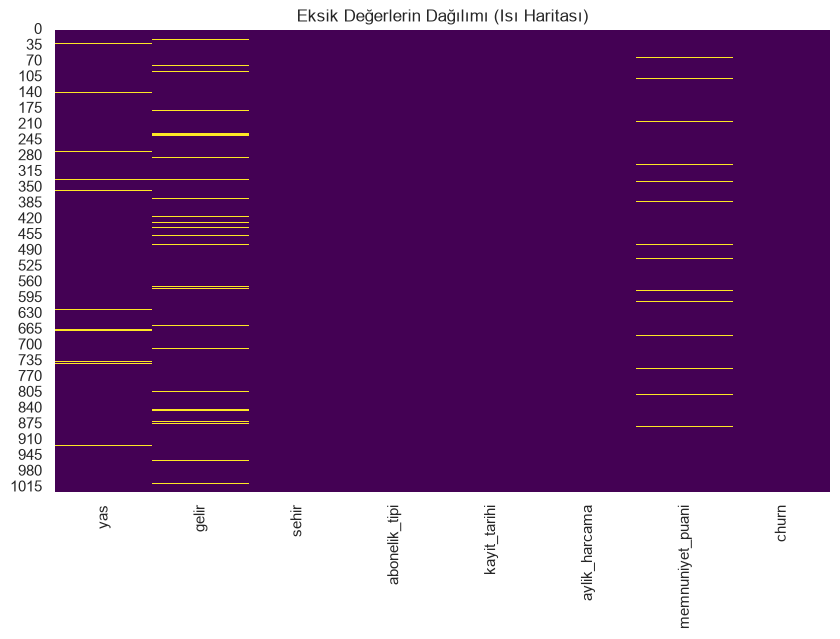

In [ ]:
# 5. Eksik Değer Analizi ve Isı Haritası

# Özet tablo: Her sütundaki eksik değer sayısı, benzersiz değer ve yüzde
eksik_sayisi = df.isnull().sum()
eksik_yuzdesi = (df.isnull().sum() / len(df)) * 100
benzersiz_sayisi = df.nunique()

ozet_tablo = pd.DataFrame(
    {
        "Eksik_Sayisi": eksik_sayisi,
        "Eksik_Yuzdesi (%)": eksik_yuzdesi,
        "Benzersiz_Deger_Sayisi": benzersiz_sayisi,
    }
)
display(ozet_tablo)

# Isı haritası (Heatmap) ile eksik değerlerin görselleştirilmesi
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Eksik Değerlerin Dağılımı (Isı Haritası)")
plt.show()

In [ ]:
#6. Yinelenen Kayıtların Tespiti

duplicate_sayisi = df.duplicated().sum()
print(f"Toplam yinelenen (duplicate) satır sayısı: {duplicate_sayisi}")

Toplam yinelenen (duplicate) satır sayısı: 25


In [ ]:
#7. Kategorik Veri Temizliği ("Şehir" Sütunu)

print("Temizlik Öncesi Şehir Dağılımı:")
print(df["sehir"].value_counts(dropna=False))

# Şehir isimlerini küçük harfe çevirme ve boşluklardan arındırma
df["sehir"] = df["sehir"].astype(str).str.lower().str.strip()

print("\nTemizlik Sonrası Şehir Dağılımı:")
print(df["sehir"].value_counts(dropna=False))

Temizlik Öncesi Şehir Dağılımı:
sehir
Ankara      188
İSTANBUL    179
İzmir       175
ANKARA      171
İstanbul    168
istanbul    144
Name: count, dtype: int64

Temizlik Sonrası Şehir Dağılımı:
sehir
ankara       359
i̇stanbul    347
i̇zmir       175
istanbul     144
Name: count, dtype: int64


In [ ]:
#8. Mantık Dışı (Anomali) Değerlerin Tespiti

anormal_yaslar = df[(df["yas"] < 0) | (df["yas"] > 100)]
print(f"Mantık dışı yaş değerine sahip kayıt sayısı: {len(anormal_yaslar)}")
display(anormal_yaslar.head())

Mantık dışı yaş değerine sahip kayıt sayısı: 10


,yas,gelir,sehir,abonelik_tipi,kayit_tarihi,aylik_harcama,memnuniyet_puani,churn
19,150.00,15728.25,ankara,Premium,2023-01-20,364.34,7.00,1
113,-5.00,8469.95,ankara,Premium,2023-04-24,74.99,7.00,0
144,-10.00,7031.19,i̇zmir,Premium,2023-05-25,355.15,9.00,0
165,300.00,9837.12,i̇stanbul,Premium,2023-06-15,251.95,9.00,0
207,-5.00,11332.79,i̇stanbul,Premium,2023-07-27,56.83,6.00,0


In [ ]:
#9. Betimsel İstatistikler

betimsel_ozet = df.describe().T
betimsel_ozet["skewness"] = df.select_dtypes(include=np.number).skew()
betimsel_ozet["kurtosis"] = df.select_dtypes(include=np.number).kurtosis()

display(betimsel_ozet)

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
yas,994.00,44.27,19.37,-20.00,31.00,44.00,56.00,300.00,3.52,39.05
gelir,976.00,12278.26,42811.18,-100000.00,8171.26,10168.56,12101.58,1000000.00,19.38,397.82
aylik_harcama,1025.00,269.06,129.55,50.08,158.00,267.98,381.16,498.93,0.05,-1.21
memnuniyet_puani,986.00,5.55,2.90,1.00,3.00,6.00,8.00,10.00,-0.02,-1.21
churn,1025.00,0.20,0.40,0.00,0.00,0.00,0.00,1.00,1.52,0.30


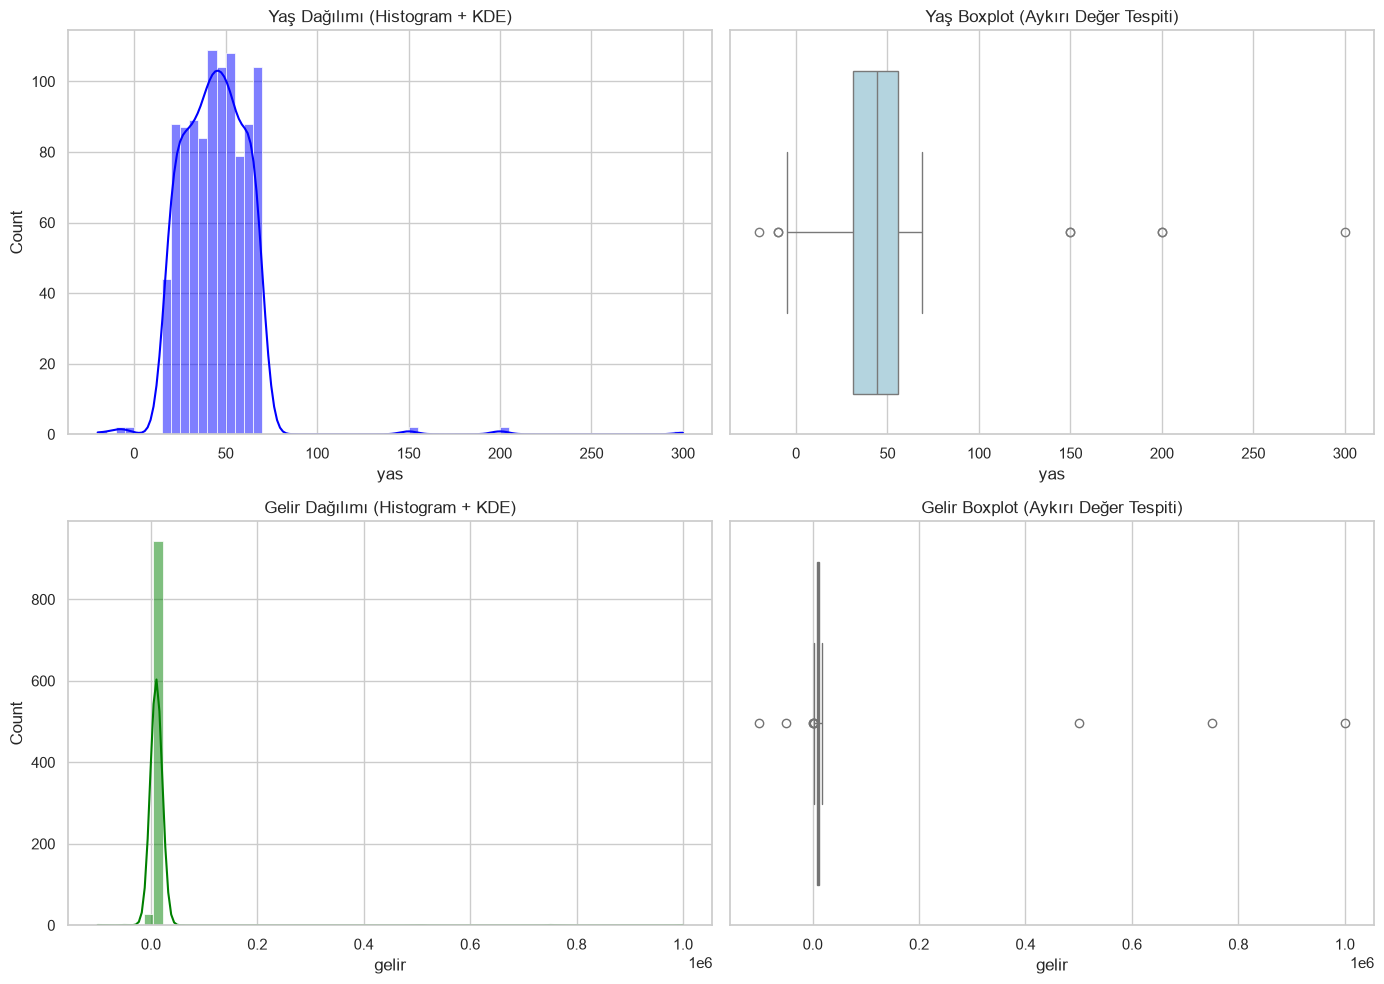

In [ ]:
#10. Dağılım Görselleştirmeleri (Histogram, KDE ve Boxplot)


fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df["yas"].dropna(), kde=True, ax=axes[0, 0], color="blue")
axes[0, 0].set_title("Yaş Dağılımı (Histogram + KDE)")

sns.boxplot(x=df["yas"].dropna(), ax=axes[0, 1], color="lightblue")
axes[0, 1].set_title("Yaş Boxplot (Aykırı Değer Tespiti)")

sns.histplot(df["gelir"].dropna(), kde=True, ax=axes[1, 0], color="green")
axes[1, 0].set_title("Gelir Dağılımı (Histogram + KDE)")

sns.boxplot(x=df["gelir"].dropna(), ax=axes[1, 1], color="lightgreen")
axes[1, 1].set_title("Gelir Boxplot (Aykırı Değer Tespiti)")

plt.tight_layout()
plt.show()

--- SEHIR Yüzdesel Dağılımı ---
sehir
ankara      35.02
i̇stanbul   33.85
i̇zmir      17.07
istanbul    14.05
Name: proportion, dtype: float64


--- ABONELIK_TIPI Yüzdesel Dağılımı ---
abonelik_tipi
Standart     46.73
Premium      31.90
Enterprise   21.37
Name: proportion, dtype: float64


--- CHURN Yüzdesel Dağılımı ---
churn
0   80.20
1   19.80
Name: proportion, dtype: float64




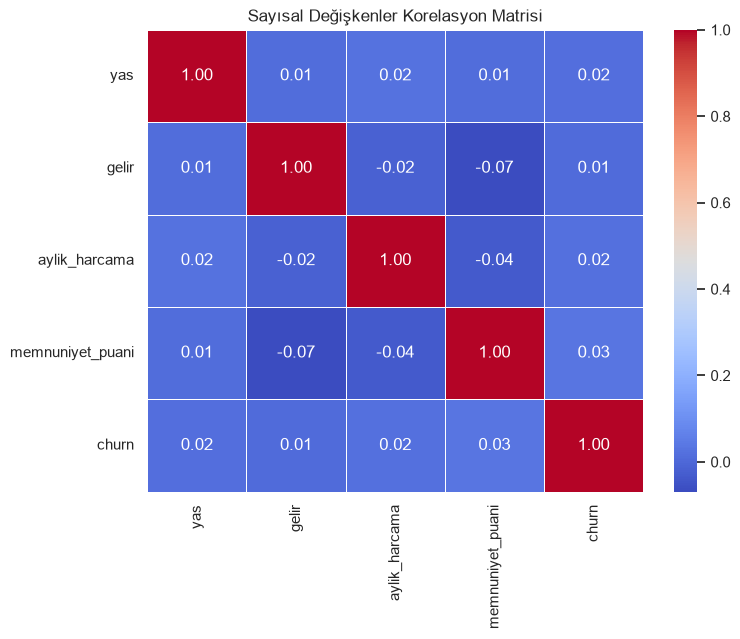

In [ ]:
#11. Kategorik Değişken Analizi ve 12. Korelasyon Analizi

for col in ["sehir", "abonelik_tipi", "churn"]:
    print(f"--- {col.upper()} Yüzdesel Dağılımı ---")
    print(df[col].value_counts(normalize=True) * 100)
    print("\n")

plt.figure(figsize=(8, 6))
corr_matrix = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Sayısal Değişkenler Korelasyon Matrisi")
plt.show()